In [16]:
!uv add pandas numpy qmap-benchmark refnd torch esm tqdm

Resolved 170 packages in 208ms                                       
Audited 166 packages in 0.03ms                                       


In [67]:
from qmap import DBAASPDataset

ds = (DBAASPDataset()
        .with_canonical_only()
        .with_l_aa_only()
        .with_length_range(min_length=0, max_length=100)
        .with_terminal_modification(False, False)
        .tabular(["id", "sequence", "Escherichia coli"])
     )
ds = ds.loc[ds["Escherichia coli"].notna()]
ds

,id,sequence,Escherichia coli
0,11,RVKRVWPLVIRTVIAGYNLYRAIKKK,2.240083
1,12,RKRIHIGPGRAFYTT,6.760000
2,15,DSHAKRHHGYKRKFHEKHHSHRGY,132.000000
3,16,ENREVPPGFTALIKTLRKCKII,13.455000
4,36,NLVSGLIEARKYLEQLHRKLKNCKV,11.510000
...,...,...,...
8975,24200,WRIRRRWPRLPRPRWRPRFPPP,0.833333
8976,24201,WRIRRRWPRLPRPRWRPRFPPPFPIPR,1.333333
8977,24202,WRIRRRWPRLPRPRWRPWFPPR,2.333333
8978,24203,WRIRRRWPRLPRPRWRPWFPPRFPIPR,1.666667


(array([  11.,   49.,  230.,  871., 1408., 1406.,  831.,  131.,   50.,
          16.]),
 array([-4.97913663, -3.43664178, -1.89414693, -0.35165209,  1.19084276,
         2.73333761,  4.27583246,  5.8183273 ,  7.36082215,  8.903317  ,
        10.44581184]),
 <BarContainer object of 10 artists>)

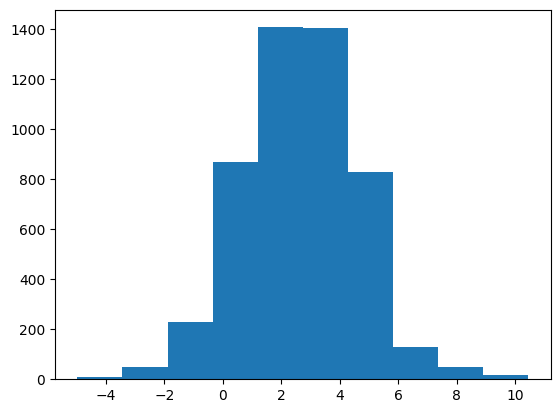

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# < 1.5 = 1 (Active) ||  > 4.5 = 0 (Inactive)
plt.hist(np.log(ds["Escherichia coli"].values))

In [69]:
np.sum(np.log(ds["Escherichia coli"]) > 4)

np.int64(1316)

In [71]:
ds["label"] = (np.log(ds["Escherichia coli"]) < 1.5).astype(np.float32)
ds.loc[(np.log(ds["Escherichia coli"]) > 1.5) & (np.log(ds["Escherichia coli"]) < 4.), "label"] = np.nan
ds
ds = ds.dropna()
np.unique(ds["label"], return_counts = True)

(array([0., 1.], dtype=float32), array([1316, 1418]))

In [72]:
import torch
from tqdm import tqdm
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig


def get_embeddings(
    peptides: list[str],
    batch_size: int = 512,
) -> torch.Tensor:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    client = ESMC.from_pretrained("esmc_300m").to(device)
    client.eval()

    pad_id = client.tokenizer.pad_token_id
    eos_id = client.tokenizer.eos_token_id

    all_embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(peptides), batch_size), desc="Embedding"):
            batch = peptides[i : i + batch_size]

            tokens_list = [
                client.encode(ESMProtein(sequence=seq)).sequence
                for seq in batch
            ]
            tokens = torch.nn.utils.rnn.pad_sequence(
                tokens_list, batch_first=True, padding_value=pad_id
            ).to(device)  # (B, L_max)

            mask = (tokens != pad_id) & (tokens != eos_id)
            mask[:, 0] = False  # exclude BOS

            emb = client(tokens).embeddings  # (B, L_max, D)

            for j in range(len(batch)):
                m = mask[j]
                all_embeddings.append(emb[j, m, :].mean(dim=0).cpu())

    return torch.stack(all_embeddings)  # (N, D)

In [75]:
embs = get_embeddings(ds["sequence"].iloc[:5])

Embedding: 100%|█████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.67it/s]


In [76]:
embs

tensor([[-0.0032, -0.0134, -0.0032,  ...,  0.0126,  0.0077, -0.0165],
        [ 0.0154, -0.0030,  0.0115,  ...,  0.0024,  0.0159, -0.0151],
        [-0.0026, -0.0399, -0.0250,  ...,  0.0172, -0.0003, -0.0165],
        [ 0.0121, -0.0034,  0.0103,  ..., -0.0152,  0.0205, -0.0099],
        [-0.0064, -0.0243,  0.0058,  ..., -0.0017,  0.0173, -0.0137]])